# Tutorial: apply a Legendre distortion model

This notebook models optical distortion with a two-dimensional Legendre expansion. Like every current warpfield distortion class, `LegendreDistortion` receives coordinates with shape `(N_coordinate, 2)` and returns coordinate **displacements** with the same shape. When `imaging_radius` is defined, `Optics` normalizes the input focal-plane coordinates by that radius before evaluating the distortion, then adds the returned displacements to the ideal coordinates.

## 1. Imports and plotting configuration

The figures use the conventions established in Tutorials 05–08: square axes, common focal-plane limits, left-aligned titles, and detector boundaries with node 0 and the first edge emphasized.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

matplotlib.rcParams['legend.frameon'] = False
matplotlib.rcParams['figure.dpi'] = 72

In [2]:
import astropy.units as u

from warpfield import Pointing, SourceCatalog
from warpfield.distortion import IdentityDistortion, LegendreDistortion
from warpfield.footprint import focalplane_footprints
from warpfield.model import get_jasmine

## 2. Define a regular sky grid

A regular source grid is placed around the origin of ICRS. The telescope optical axis is centered on the grid with position angle 0°. This is the same input geometry used in Tutorial 08, allowing the SIP and Legendre examples to be compared directly.

In [3]:
axis = np.linspace(-0.24, 0.24, 25)
ra, dec = np.meshgrid(axis, axis)
source = SourceCatalog(ra.ravel(), dec.ravel())
pointing = Pointing.from_coord(
  'icrs',
  0.0 * u.deg,
  0.0 * u.deg,
  0.0 * u.deg,
)

The helpers below evaluate the telescope and draw its nominal detector boundaries. `focalplane_footprints()` intentionally excludes distortion because a distorted detector boundary would require the inverse detector mapping.

In [4]:
def project_sources(telescope, pointing, source):
  size = len(source)
  return np.asarray(
    telescope.focal_plane(
      np.full(size, pointing.ra[0]),
      np.full(size, pointing.dec[0]),
      np.full(size, pointing.position_angle[0]),
      source.ra,
      source.dec,
      np.ones((size, 1)),
    )
  )


def plot_focal_plane(ax, telescope, pointing, source, title):
  source_xy = project_sources(telescope, pointing, source)
  ax.scatter(source_xy[:, 0], source_xy[:, 1], s=5)
  for detector_id, boundary in enumerate(focalplane_footprints(telescope)):
    N = boundary.shape[0]
    ax.scatter(
      boundary[0, 0],
      boundary[0, 1],
      color=f'C{detector_id}',
      marker='o',
      s=25,
    )
    ax.plot(
      boundary[: N // 4 + 1, 0],
      boundary[: N // 4 + 1, 1],
      color=f'C{detector_id}',
      lw=3,
    )
    ax.plot(
      boundary[:, 0],
      boundary[:, 1],
      color=f'C{detector_id}',
      lw=1,
    )
  radius = telescope.optics.imaging_radius
  ax.add_patch(
    plt.Circle(
      (0.0, 0.0),
      radius,
      fill=False,
      color='gray',
      ls='--',
      lw=1,
    )
  )
  limit = 1.05 * radius
  ax.set_xlim(-limit, limit)
  ax.set_ylim(-limit, limit)
  ax.set_aspect(1.0, adjustable='box')
  ax.grid(True, color='gray', alpha=0.5)
  ax.set_title(title, loc='left')
  ax.set_xlabel('Focal plane X (mm)')
  ax.set_ylabel('Focal plane Y (mm)')

## 3. Identity distortion

`get_jasmine()` returns a plain `Telescope` with `IdentityDistortion` by default. The identity model returns zero displacement, so the projected sky grid retains its regular shape.

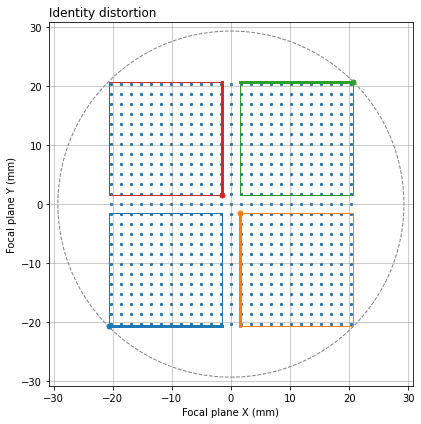

In [5]:
identity = get_jasmine()

assert isinstance(identity.optics.distortion, IdentityDistortion)

fig, ax = plt.subplots(figsize=(6, 6))
plot_focal_plane(
  ax,
  identity,
  pointing,
  source,
  title='Identity distortion',
)
fig.tight_layout()
plt.show()

## 4. Construct a Legendre distortion

For normalized coordinates $(u,v)$, a two-dimensional Legendre expansion has the form

$$
\Delta x(u,v) = \sum_{i,j} A_{ij} L_i(u)L_j(v), \qquad
\Delta y(u,v) = \sum_{i,j} B_{ij} L_i(u)L_j(v).
$$

`LegendreDistortion` stores 18 coefficients for each displacement component: 3 second-order, 4 third-order, 5 fourth-order, and 6 fifth-order coefficients. Constant and affine coefficients are omitted. `Optics` divides the focal-plane coordinates by `imaging_radius`, mapping the valid circular field into `[-1, 1]` on each axis. The Legendre coefficients and returned displacements remain in millimeters. The coefficients below are intentionally pronounced so that the deformation is easy to see.

In [6]:
coeff_x = np.zeros(18)
coeff_y = np.zeros(18)

# Third-order ordering: L3(u), L2(u)L1(v), L1(u)L2(v), L3(v)
coeff_x[[3, 5]] = [3.6, 2.4]
coeff_y[[4, 6]] = [2.4, 3.6]

legendre = LegendreDistortion(
  coeff_x=coeff_x,
  coeff_y=coeff_y,
)
distorted = get_jasmine(distortion=legendre)

The distortion model can be evaluated independently of the telescope. To reproduce the `Optics` convention, focal-plane coordinates are divided by `imaging_radius` first. The following quiver plot makes the sign, symmetry, and approximate displacement scale visible before applying it to sky coordinates.

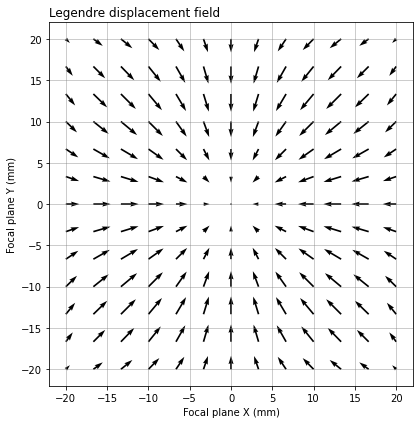

In [7]:
vector_axis = np.linspace(-20.0, 20.0, 13)
grid_x, grid_y = np.meshgrid(vector_axis, vector_axis)
grid_xy = np.column_stack([grid_x.ravel(), grid_y.ravel()])
normalized_xy = grid_xy / distorted.optics.imaging_radius
displacement = np.asarray(legendre(normalized_xy))

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(
  grid_xy[:, 0],
  grid_xy[:, 1],
  displacement[:, 0],
  displacement[:, 1],
  angles='xy',
  scale_units='xy',
  scale=1.0,
)
ax.set_xlim(-22.0, 22.0)
ax.set_ylim(-22.0, 22.0)
ax.set_aspect(1.0, adjustable='box')
ax.grid(True, color='gray', alpha=0.5)
ax.set_title('Legendre displacement field', loc='left')
ax.set_xlabel('Focal plane X (mm)')
ax.set_ylabel('Focal plane Y (mm)')
fig.tight_layout()
plt.show()

## 5. Compare the projected coordinates

Both panels use identical sources, pointing, detector geometry, and display limits. Only `Optics.distortion` differs. The smooth Legendre displacement bends the regular grid while preserving the nominal detector outlines used as a visual reference.

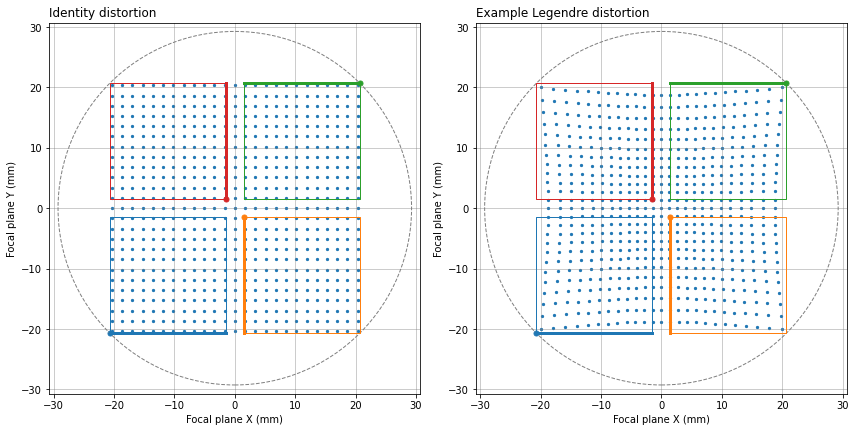

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_focal_plane(
  axes[0],
  identity,
  pointing,
  source,
  title='Identity distortion',
)
plot_focal_plane(
  axes[1],
  distorted,
  pointing,
  source,
  title='Example Legendre distortion',
)
fig.tight_layout()
plt.show()

## Summary

- `LegendreDistortion` returns displacement arrays with shape `(N_coordinate, 2)`.
- `Optics` uses `imaging_radius` to normalize focal-plane coordinates before evaluating the Legendre basis.
- The two 18-element arrays contain second- through fifth-order coefficients for the X and Y displacements.
- The coefficients are differentiable Zodiax leaves.
- Passing the model through `get_jasmine(distortion=...)` changes only the nominal instrument's optical distortion.